# 월간 데이콘 심리 성향 예측 — 투표 안 한 확률 예측
- **타겟**: voted=1(투표 안 함) 확률
- **평가**: AUC, Accuracy
- **모델**: LightGBM + XGBoost + CatBoost (Soft Voting 앙상블)
- **검증**: Stratified 5-Fold OOF

## 0. 라이브러리

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'AppleGothic'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test_x.csv')
sub   = pd.read_csv('sample_submission.csv')

print('Train:', train.shape)
print('Test :', test.shape)

# voted: 1=투표 안 함, 2=투표 함
# 타겟 = 투표 안 한 확률 → y=1 이 '투표 안 함'
print('\n타겟 분포:')
print(train['voted'].value_counts())
print('  1=투표안함, 2=투표함')

Train: (45532, 78)
Test : (11383, 77)

타겟 분포:
voted
2    24898
1    20634
Name: count, dtype: int64
  1=투표안함, 2=투표함


## 2. 피처 엔지니어링

In [3]:
def build_features(df):
    df = df.copy()

    # ── QA 수치 변환
    qa_cols = [f'Q{chr(97+i)}A' for i in range(20)]
    for c in qa_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(3)

    # ── MACH-IV 역채점 (QcA, QfA, QiA, QkA, QlA, QqA)
    reverse_mach = ['QcA','QfA','QiA','QkA','QlA','QqA']
    for c in reverse_mach:
        df[c] = 6 - df[c]

    # MACH-IV 하위척도
    tactics  = ['QaA','QbA','QdA','QeA','QhA','QjA','QmA','QoA','QpA','QsA','QtA']
    views    = ['QcA','QgA','QiA','QnA','QrA']
    morality = ['QfA','QkA','QlA','QqA']
    df['mach_tactics']  = df[tactics].mean(axis=1)
    df['mach_views']    = df[views].mean(axis=1)
    df['mach_morality'] = df[morality].mean(axis=1)
    df['mach_total']    = df[qa_cols].mean(axis=1)

    # ── TIPI Big Five 역채점
    reverse_tipi = ['tp02','tp06','tp08','tp09','tp10']
    for c in reverse_tipi:
        df[c] = 8 - df[c].astype(float)
    df['big5_E'] = (df['tp01'] + df['tp06']) / 2  # 외향성
    df['big5_A'] = (df['tp07'] + df['tp02']) / 2  # 친화성
    df['big5_C'] = (df['tp03'] + df['tp08']) / 2  # 성실성 ★
    df['big5_N'] = (df['tp04'] + df['tp09']) / 2  # 신경성
    df['big5_O'] = (df['tp05'] + df['tp10']) / 2  # 개방성

    # ── QE 응답시간 피처
    qe_cols = [f'Q{chr(97+i)}E' for i in range(20)]
    qe = df[qe_cols].astype(float).clip(upper=60_000)
    df['qe_mean']    = np.log1p(qe.mean(axis=1))
    df['qe_std']     = qe.std(axis=1)             # 핵심 신호 (-21.8%)
    df['qe_cv']      = df['qe_std'] / (qe.mean(axis=1) + 1e-6)
    df['qe_max']     = np.log1p(qe.max(axis=1))
    # 망설임 지수
    qa_arr = df[qa_cols].values
    df['hesitation'] = (qe.values / (np.abs(qa_arr - 3) + 1)).mean(axis=1)

    # ── wr / wf 집계
    wr_cols = [f'wr_{i:02d}' for i in range(1, 14)]
    df['wr_sum'] = df[wr_cols].sum(axis=1)
    df['wf_sum'] = df[['wf_01','wf_02','wf_03']].sum(axis=1)

    # ── 교차 피처
    df['C_x_tactics']  = df['big5_C'] * df['mach_tactics']
    df['N_x_morality'] = df['big5_N'] * df['mach_morality']
    df['A_x_views']    = df['big5_A'] * df['mach_views']

    # ── familysize 이상치
    df['familysize'] = df['familysize'].clip(upper=20)

    return df

train = build_features(train)
test  = build_features(test)
print('피처 엔지니어링 완료')
print('Train 컬럼 수:', train.shape[1])

피처 엔지니어링 완료
Train 컬럼 수: 97


## 3. 전처리

In [4]:
# voted: 1=투표안함(양성), 2=투표함(음성) → y=1이 '투표 안 함'
y = (train['voted'] == 1).astype(int).values
print('타겟(투표안함=1) 비율:', y.mean().round(4))

# 범주형 인코딩
cat_cols = ['age_group','gender','race','religion']
for c in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[c], test[c]], axis=0).astype(str)
    le.fit(combined)
    train[c] = le.transform(train[c].astype(str))
    test[c]  = le.transform(test[c].astype(str))

# 피처 선택 (index, voted 제외)
drop_cols = ['index','voted']
feat_cols = [c for c in train.columns if c not in drop_cols]

X      = train[feat_cols].astype(float)
X_test = test[feat_cols].astype(float)

print('피처 수:', len(feat_cols))
print('결측값:', X.isnull().sum().sum())

타겟(투표안함=1) 비율: 0.4532
피처 수: 95
결측값: 0


## 4. 모델 학습 — Stratified 5-Fold OOF

In [5]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# OOF / 테스트 예측 저장
oof_lgb = np.zeros(len(y))
oof_xgb = np.zeros(len(y))
oof_cat = np.zeros(len(y))

test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_cat = np.zeros(len(X_test))

# ── LightGBM 파라미터
lgb_params = dict(
    objective='binary', metric='auc',
    n_estimators=1000, learning_rate=0.05,
    num_leaves=63, max_depth=-1,
    min_child_samples=20, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, random_state=SEED,
    verbose=-1, n_jobs=-1
)

# ── XGBoost 파라미터
xgb_params = dict(
    objective='binary:logistic', eval_metric='auc',
    n_estimators=1000, learning_rate=0.05,
    max_depth=6, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, random_state=SEED,
    verbosity=0, n_jobs=-1
)

# ── CatBoost 파라미터
cat_params = dict(
    iterations=1000, learning_rate=0.05,
    depth=6, l2_leaf_reg=3,
    random_seed=SEED, eval_metric='AUC',
    verbose=0
)

print('='*55)
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    # ── LightGBM
    m_lgb = lgb.LGBMClassifier(**lgb_params)
    m_lgb.fit(X_tr, y_tr,
              eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)])
    oof_lgb[va_idx]  = m_lgb.predict_proba(X_va)[:, 1]
    test_lgb        += m_lgb.predict_proba(X_test)[:, 1] / N_FOLDS

    # ── XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_params)
    m_xgb.fit(X_tr, y_tr,
              eval_set=[(X_va, y_va)],
              verbose=False)
    oof_xgb[va_idx]  = m_xgb.predict_proba(X_va)[:, 1]
    test_xgb        += m_xgb.predict_proba(X_test)[:, 1] / N_FOLDS

    # ── CatBoost
    m_cat = CatBoostClassifier(**cat_params)
    m_cat.fit(X_tr, y_tr,
              eval_set=(X_va, y_va),
              early_stopping_rounds=50)
    oof_cat[va_idx]  = m_cat.predict_proba(X_va)[:, 1]
    test_cat        += m_cat.predict_proba(X_test)[:, 1] / N_FOLDS

    # Fold 결과
    auc_lgb = roc_auc_score(y_va, oof_lgb[va_idx])
    auc_xgb = roc_auc_score(y_va, oof_xgb[va_idx])
    auc_cat = roc_auc_score(y_va, oof_cat[va_idx])
    print(f'Fold {fold} | LGB {auc_lgb:.4f} | XGB {auc_xgb:.4f} | CAT {auc_cat:.4f}')

print('='*55)

Fold 1 | LGB 0.7792 | XGB 0.7684 | CAT 0.7799
Fold 2 | LGB 0.7682 | XGB 0.7548 | CAT 0.7674
Fold 3 | LGB 0.7626 | XGB 0.7557 | CAT 0.7623
Fold 4 | LGB 0.7610 | XGB 0.7500 | CAT 0.7599
Fold 5 | LGB 0.7683 | XGB 0.7567 | CAT 0.7679


## 5. 평가 지표 — AUC & Accuracy

In [6]:
# 앙상블: 단순 평균
oof_ensemble  = (oof_lgb + oof_xgb + oof_cat) / 3
test_ensemble = (test_lgb + test_xgb + test_cat) / 3

# ── AUC
auc_lgb = roc_auc_score(y, oof_lgb)
auc_xgb = roc_auc_score(y, oof_xgb)
auc_cat = roc_auc_score(y, oof_cat)
auc_ens = roc_auc_score(y, oof_ensemble)

# ── Accuracy (threshold=0.5)
acc_lgb = accuracy_score(y, (oof_lgb  >= 0.5).astype(int))
acc_xgb = accuracy_score(y, (oof_xgb  >= 0.5).astype(int))
acc_cat = accuracy_score(y, (oof_cat  >= 0.5).astype(int))
acc_ens = accuracy_score(y, (oof_ensemble >= 0.5).astype(int))

result_df = pd.DataFrame({
    '모델':     ['LightGBM', 'XGBoost', 'CatBoost', '앙상블(평균)'],
    'OOF AUC':  [auc_lgb, auc_xgb, auc_cat, auc_ens],
    'Accuracy': [acc_lgb, acc_xgb, acc_cat, acc_ens],
}).set_index('모델')

print(result_df.round(4))

          OOF AUC  Accuracy
모델                         
LightGBM   0.7675    0.6957
XGBoost    0.7571    0.6842
CatBoost   0.7674    0.6966
앙상블(평균)    0.7678    0.6954


## 6. 시각화

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

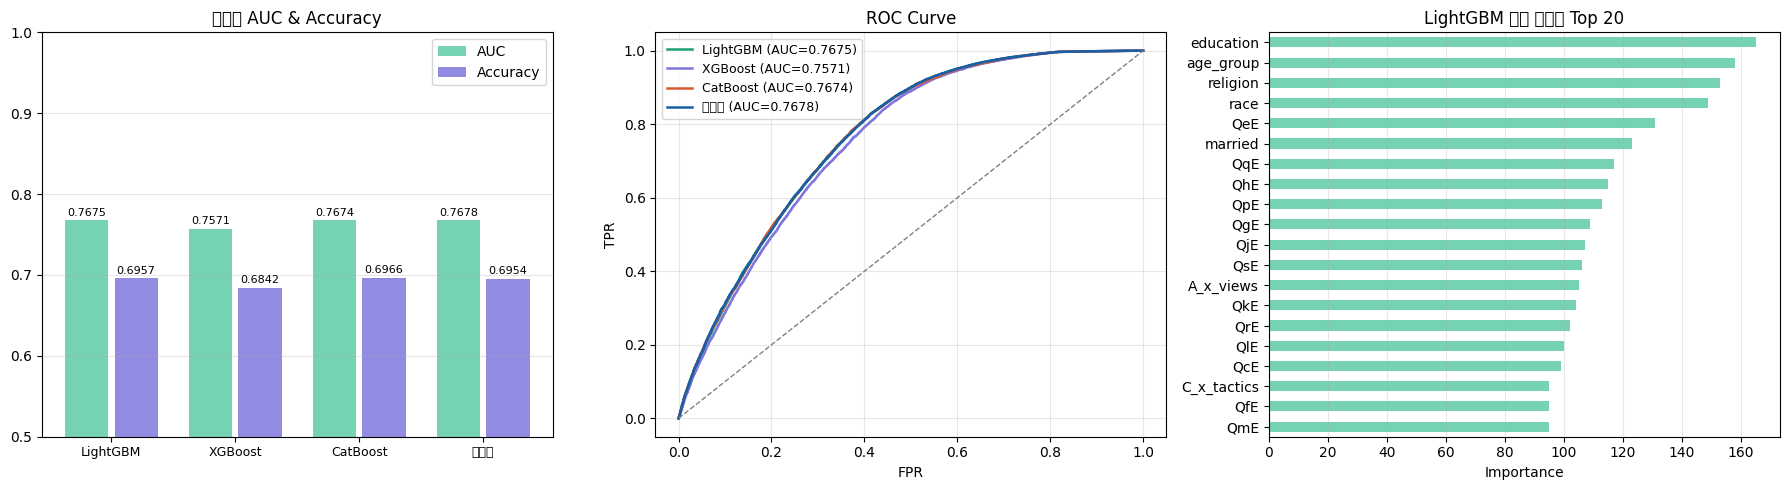

evaluation.png 저장 완료


In [7]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (1) AUC / Accuracy 비교
ax = axes[0]
x = np.arange(4)
labels = ['LightGBM','XGBoost','CatBoost','앙상블']
aucs   = [auc_lgb, auc_xgb, auc_cat, auc_ens]
accs   = [acc_lgb, acc_xgb, acc_cat, acc_ens]
bars1 = ax.bar(x - 0.2, aucs, 0.35, label='AUC',      color='#5DCAA5', alpha=0.85)
bars2 = ax.bar(x + 0.2, accs, 0.35, label='Accuracy', color='#7F77DD', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0.5, 1.0); ax.set_title('모델별 AUC & Accuracy', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for b in bars1: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for b in bars2: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)

# ── (2) ROC Curve
ax = axes[1]
for preds, name, color in [
    (oof_lgb,      'LightGBM', '#1D9E75'),
    (oof_xgb,      'XGBoost',  '#7F77DD'),
    (oof_cat,      'CatBoost', '#D85A30'),
    (oof_ensemble, '앙상블',    '#185FA5'),
]:
    fpr, tpr, _ = roc_curve(y, preds)
    auc_val = roc_auc_score(y, preds)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})', color=color, lw=1.8)
ax.plot([0,1],[0,1],'--', color='gray', lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── (3) LightGBM 피처 중요도 Top 20
ax = axes[2]
imp = pd.Series(m_lgb.feature_importances_, index=feat_cols).sort_values(ascending=False).head(20)
imp[::-1].plot.barh(ax=ax, color='#5DCAA5', alpha=0.85)
ax.set_title('LightGBM 피처 중요도 Top 20', fontsize=12)
ax.set_xlabel('Importance'); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('evaluation.png 저장 완료')

## 7. 앙상블 가중치 최적화

In [8]:
from scipy.optimize import minimize

def neg_auc(weights):
    w = np.array(weights)
    w = np.abs(w) / np.abs(w).sum()   # 정규화
    blend = w[0]*oof_lgb + w[1]*oof_xgb + w[2]*oof_cat
    return -roc_auc_score(y, blend)

res = minimize(neg_auc, x0=[1/3, 1/3, 1/3],
               method='Nelder-Mead', options={'maxiter': 1000})

w_opt = np.abs(res.x) / np.abs(res.x).sum()
print(f'최적 가중치 → LGB: {w_opt[0]:.3f} | XGB: {w_opt[1]:.3f} | CAT: {w_opt[2]:.3f}')

oof_weighted  = w_opt[0]*oof_lgb  + w_opt[1]*oof_xgb  + w_opt[2]*oof_cat
test_weighted = w_opt[0]*test_lgb + w_opt[1]*test_xgb + w_opt[2]*test_cat

auc_weighted = roc_auc_score(y, oof_weighted)
acc_weighted = accuracy_score(y, (oof_weighted >= 0.5).astype(int))
print(f'가중 앙상블 OOF AUC : {auc_weighted:.4f}')
print(f'가중 앙상블 Accuracy: {acc_weighted:.4f}')

최적 가중치 → LGB: 0.478 | XGB: 0.099 | CAT: 0.423
가중 앙상블 OOF AUC : 0.7691
가중 앙상블 Accuracy: 0.6969


## 8. 최종 결과 요약

In [9]:
final_df = pd.DataFrame({
    '모델': ['LightGBM','XGBoost','CatBoost','앙상블(평균)','앙상블(최적가중치)'],
    'OOF AUC':  [auc_lgb, auc_xgb, auc_cat, auc_ens, auc_weighted],
    'Accuracy': [acc_lgb, acc_xgb, acc_cat, acc_ens, acc_weighted],
}).set_index('모델')

print('='*45)
print(final_df.round(4).to_string())
print('='*45)
best_model = final_df['OOF AUC'].idxmax()
print(f'최고 AUC 모델: {best_model} ({final_df.loc[best_model,"OOF AUC"]:.4f})')

            OOF AUC  Accuracy
모델                           
LightGBM     0.7675    0.6957
XGBoost      0.7571    0.6842
CatBoost     0.7674    0.6966
앙상블(평균)      0.7678    0.6954
앙상블(최적가중치)   0.7691    0.6969
최고 AUC 모델: 앙상블(최적가중치) (0.7691)


## 9. 제출 파일 생성

In [10]:
# 투표 안 한 확률 (가중 앙상블) 제출
sub['voted'] = test_weighted
sub.to_csv('submission.csv', index=False)

print('submission.csv 저장 완료!')
print(f'예측값 범위: {test_weighted.min():.4f} ~ {test_weighted.max():.4f}')
print(f'예측값 평균: {test_weighted.mean():.4f}')
sub.head(10)

submission.csv 저장 완료!
예측값 범위: 0.0260 ~ 0.8298
예측값 평균: 0.4525


,index,voted
0,0,0.335958
1,1,0.130224
2,2,0.535545
3,3,0.783258
4,4,0.249203
5,5,0.493853
6,6,0.120961
7,7,0.428404
8,8,0.657023
9,9,0.433023


In [11]:
# 1 - 예측값으로 submission.csv 생성
sub_inv = sub.copy()
sub_inv['voted'] = 1 - test_weighted
sub_inv.to_csv('submission.csv', index=False)

print('submission.csv 저장 완료! (1 - 예측값 적용)')
print(f'예측값 범위: {sub_inv["voted"].min():.4f} ~ {sub_inv["voted"].max():.4f}')
print(f'예측값 평균: {sub_inv["voted"].mean():.4f}')
sub_inv.head(10)

submission.csv 저장 완료! (1 - 예측값 적용)
예측값 범위: 0.1702 ~ 0.9740
예측값 평균: 0.5475


,index,voted
0,0,0.664042
1,1,0.869776
2,2,0.464455
3,3,0.216742
4,4,0.750797
5,5,0.506147
6,6,0.879039
7,7,0.571596
8,8,0.342977
9,9,0.566977
